In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, measure, validation,
                            plotting, analysis, multicat, selection, core, stack)
from utils_lya_halo.stack import build_stacks
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins

LYA_REST = PipelineConfig.LYA_REST

import warnings
from astropy.utils.exceptions import AstropyUserWarning

warnings.filterwarnings(
    "ignore",
    message="Input data contains invalid values.*",
    category=AstropyUserWarning,
)

# Reading in output and stacking

In [2]:
# ---------------------------------------------------------------- INPUTS
random_seed     = 10
bin_mode        = 'kpc'
bins            = [0, 10, 20, 30, 50, 80, 140, 300, 600, 1000, 2000]
field           = 'BOTH'

half_width      = 3.0            # +/- Angstrom around LYA_REST used as the "line" (Stage 3)
vr_approx       = 80             # rough |v| scale (km/s) -- not consumed in this cell;
                                # handy later e.g. plot_centroid_profile(..., ylims=(-3*vr_approx, 3*vr_approx))
stack_method    = 'biweight'
mask_method     = "segmap"

id_col          = "ID"

bg_inner_arcsec = 80
bg_outer_arcsec = 90

rest_wave_min   = 1100
rest_wave_max   = 1700
spexlim         = (rest_wave_min, rest_wave_max)

n_bootstrap     = 3000
np.random.seed(random_seed)    # reproducibility for anything you resample by hand below

# ---------------------------------------------------------------- CONFIG (drives everything below)
cfg2 = replace(cfg,
    field=field,
    bin_mode=bin_mode,
    bins=bins,
    mask_method=mask_method,
    bg_inner_arcsec=bg_inner_arcsec,
    bg_outer_arcsec=bg_outer_arcsec,
    rest_wave_min=rest_wave_min,
    rest_wave_max=rest_wave_max,
    n_bootstrap=n_bootstrap,
    #flux_unit='flux_arcsec2',
    #rest_density=False,
    line_window=[LYA_REST - half_width, LYA_REST + half_width])

# ---------------------------------------------------------------- FILE PATHS
# one dict keyed by bin_mode -- add a new bin_mode by adding a key, no new elif
PRODUCT_PATHS = {
    'virial': {
        'AEGIS':  './outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits',
        'COSMOS': './outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits',
    },
    'kpc': {
        'AEGIS':  './outputs/galaxy_cat65a007_b10_ec8c16_AEGIS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
        'COSMOS': './outputs/galaxy_cat65a007_b10_ec8c16_COSMOS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
    },
}
try:
    paths = PRODUCT_PATHS[bin_mode.lower()]
except KeyError:
    raise ValueError(f"No file paths registered for bin_mode={bin_mode!r} "
                     f"(have: {list(PRODUCT_PATHS)}); add it to PRODUCT_PATHS.")

# ---------------------------------------------------------------- LOAD + CUT (per field)
products = {
    label: apply_finite_cut(read_galaxy_fits(path),
                            cfg2.cut_radial_bin, cfg2.min_good_wave)
    for label, path in paths.items()
}
product1, product2 = products['AEGIS'], products['COSMOS']   # kept for compatibility with older cells

# ---------------------------------------------------------------- (BOTH) COMBINE + STACK
prod_combined = multicat.combine_products(products, label_col="SUBSET")

print(f"AEGIS: {np.round(np.median(product1.nfib, axis=0), 3).astype(int)}")
print(f"COSMOS: {np.round(np.median(product2.nfib, axis=0), 3).astype(int)}")
print(f"COMBINED: {np.round(np.median(prod_combined.nfib, axis=0), 3).astype(int)}")

# ---------------------------------------------------------------- (SINGLE) COMBINE + STACK
stacks_by_field = multicat.stack_each(cfg2, products, keep_cube=True)   # {'AEGIS':stacks,'COSMOS':stacks}
stacks_all = stack.build_stacks(cfg2, prod_combined, keep_cube=True)

print(f"BOTH:   {prod_combined.ngal} galaxies")
print(f"AEGIS:  {products['AEGIS'].ngal} galaxies")
print(f"COSMOS: {products['COSMOS'].ngal} galaxies")

# ---------------------------------------------------------------- SEPARATE AGN
sel_agn = prod_combined.catalog["CLEAN"]

groups = selection.split_by_mask(prod_combined, sel_agn, labels=["AGN", "GAL"], verbose=False)
prod_galaxy = groups['GAL']
prod_agn = groups['AGN']

stacks = build_stacks(cfg2, prod_galaxy, keep_cube=True)
stacks_agn = build_stacks(cfg2, prod_agn, keep_cube=True)

print(f"GAL: {prod_galaxy.ngal} sources")
print(f"AGN: {prod_agn.ngal} sources")

Finite-spectrum cut (bin 9, > 100 px): kept 233 / 244 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 277 / 278 galaxies
combined 2 products -> 510 galaxies (origin in column 'SUBSET')
COSMOS: [    24     70    115    373    911   3128  16911  62091 126573 586721]
AEGIS: [    15     43     70    220    536   1809   9820  37073  87936 402380]
COMBINED: [    17     51     81    258    615   2038  10906  41317  97244 448919]
BOTH:   510 galaxies
AEGIS:  233 galaxies
COSMOS: 277 galaxies
GAL: 443 sources
AGN: 67 sources


# Measuring

In [ ]:
#BOOTSTRAP!
boot_b = measure.measure_all_bins(cfg2, stacks,
    seed=random_seed,
    verbose=True)

In [ ]:
boot = boot_b

# Lya sweep robustness test

In [ ]:
cmp = analysis.measure_centroid_methods(
    stacks, config=cfg2, nboot=cfg2.n_bootstrap,
    methods=("fw_clip", "fw_noclip", "flux_median", "gaussian", "gauss_weighted"),
    bounds=cfg2.line_window, seed=random_seed)

In [ ]:
analysis.plot_centroid_methods(cmp, stacks,
    bin_mode='kpc',
    #vr_ticks=(0.1, 0.2, 0.5, 1, 2, 5, 10, 20),
    ylims=(-300, 300),
    xlims=xlims,
    jitter=0.05,
    figsize=(8, 5),
    title=f"Centroid vs. radius by estimator (+/-{cfg2.line_window}A window)",
    save_fig=False)

In [13]:
sweep_line = validation.sweep_line_window(cfg2, stacks,
     half_windows=(3, 3.25, 3.5, 3.75, 4),
     nboot=500,
     seed=random_seed)

window ±3 Å ...


  0%|          | 0/500 [00:00<?, ?it/s]

window ±3.25 Å ...


  0%|          | 0/500 [00:00<?, ?it/s]

window ±3.5 Å ...


  0%|          | 0/500 [00:00<?, ?it/s]

window ±3.75 Å ...


  0%|          | 0/500 [00:00<?, ?it/s]

window ±4 Å ...


  0%|          | 0/500 [00:00<?, ?it/s]

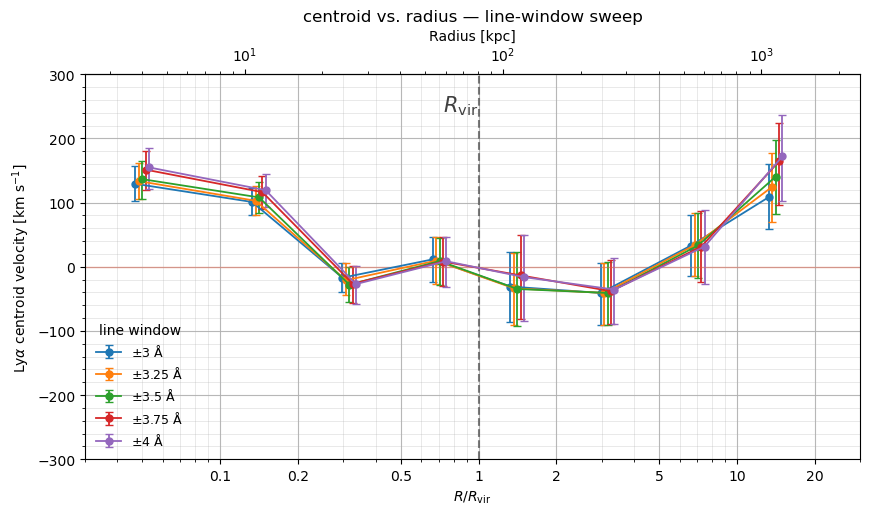

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'centroid vs. radius — line-window sweep'}, xlabel='$R/R_{\\rm vir}$', ylabel='Ly$\\alpha$ centroid velocity [km s$^{-1}$]'>)

In [14]:
validation.plot_window_sweep(sweep_line,
    vr_ticks=(0.1, 0.2, 0.5, 1, 2, 5, 10, 20),
    figsize=(10, 5),
    ylims=(-300, 300),
    xlims=(0.03, 30),
    jitter=0.03,
    title=None,
    save_fig=False)

# Continuum Bound Sweep Robustness

In [15]:
'''
Median - Highly stable across varying window sizes
Poly 1 - Decently stable across varying window sizes
'''

'\nMedian - Highly stable across varying window sizes\nPoly 1 - \n'

In [21]:
combos = [
    ("median--",     "median",   1, ((1190, 1205), (1225, 1240))),
    ("median-",     "median",   1, ((1190, 1205), (1225, 1250))),
    ("median",     "median",   1, ((1180, 1205), (1225, 1260))),
    ("median+",     "median",   1, ((1170, 1205), (1225, 1280))),
    ("median++",    "median",   1, ((1165, 1205), (1225, 1290))),
]
sweep_cont = validation.sweep_continuum_method(cfg2, 
   stacks, 
   combos=combos,
   nboot=500,
   method=None,
   seed=random_seed,
   verbose=True)

continuum: median-- ...


  0%|          | 0/500 [00:00<?, ?it/s]

continuum: median- ...


  0%|          | 0/500 [00:00<?, ?it/s]

continuum: median ...


  0%|          | 0/500 [00:00<?, ?it/s]

continuum: median+ ...


  0%|          | 0/500 [00:00<?, ?it/s]

continuum: median++ ...


  0%|          | 0/500 [00:00<?, ?it/s]

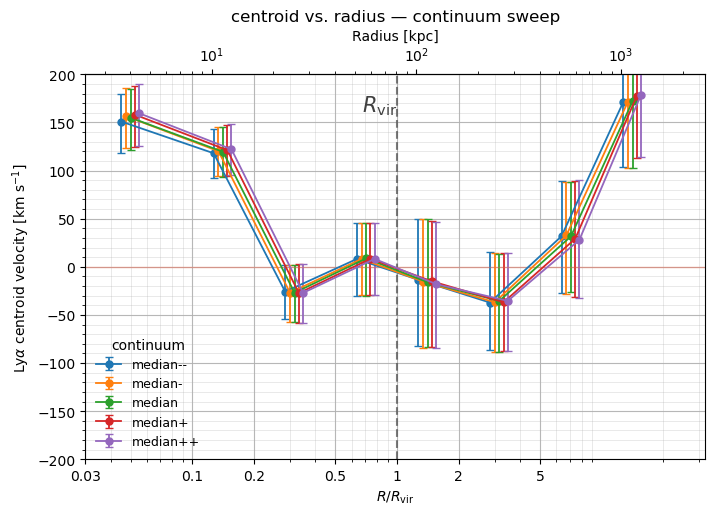

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'centroid vs. radius — continuum sweep'}, xlabel='$R/R_{\\rm vir}$', ylabel='Ly$\\alpha$ centroid velocity [km s$^{-1}$]'>)

In [23]:
validation.plot_continuum_sweep(sweep_cont,
    statistic="centroid",
    vr_ticks=(0.03, 0.1, 0.2, 0.5, 1, 2, 5),
    figsize=(8, 5),
    ylims="auto", 
    xlims=None, 
    jitter=0.05, 
    title=None,
    save_fig=True)

# Bootstrap vs Jackknife

In [24]:
xcheck = validation.error_cross_check(
    cfg2, stacks,
    product=combined,      # needed for group jackknife (leave-one-field-out)
    group_col="FIELD",    # column in your catalog with the field name
    n_blocks=10,
    statistic="centroid", # or "flux"
    nboot=1000,
    verbose=True)         # prints a table: boot | block JK | group JK | ratio

  0%|          | 0/1000 [00:00<?, ?it/s]


error cross-check (centroid, method=biweight, 10 blocks, +group JK):
           bin       boot   block JK   JK/boot   group JK
         0-0.1       34.6         38      1.10       52.6
       0.1-0.2       24.5       21.6      0.88       16.8
       0.2-0.5       27.7       32.9      1.19       22.6
         0.5-1       41.1       20.6      0.50       11.6
           1-2       60.8       64.9      1.07       6.37
           2-5       51.6       50.8      0.99       36.1
          5-10       60.1       57.2      0.95         87
         10-20       63.2       67.1      1.06         48


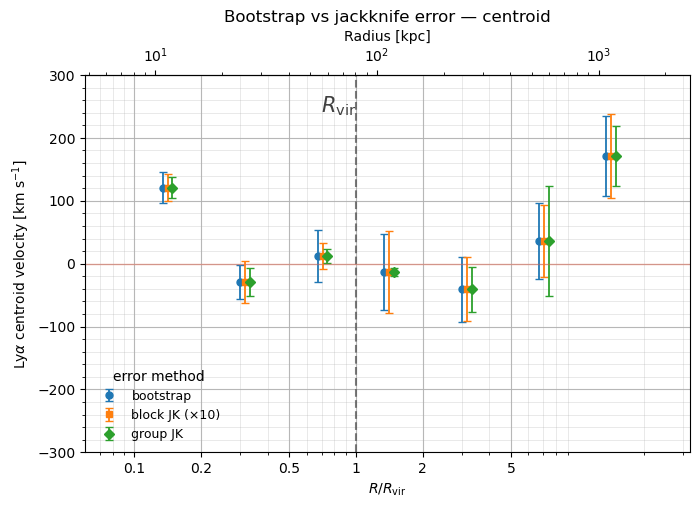

(<Figure size 780x490 with 1 Axes>,
 <Axes: title={'center': 'Bootstrap vs jackknife error — centroid'}, xlabel='$R/R_{\\rm vir}$', ylabel='Ly$\\alpha$ centroid velocity [km s$^{-1}$]'>)

In [30]:
validation.plot_error_cross_check(xcheck, ylims=(-300, 300), save_fig=False)

# Injection-Recovery of Signal Centroid

In [ ]:
rec = validation.injection_recovery(
    cfg2, combined,
    methods=("fw_clip", "gaussian", "flux_median"),
    stack_method=stack_method,
    v_inputs=(-150, -75, 0, 75, 150),
    snr=5.0, 
    sigma_A=1.2, 
    nboot=300,
    n_noise=10,
    seed=random_seed,
    verbose=True)

In [59]:
"""
injection_bias_scramble.py -- decoupled bias diagnostic, ORIGINAL scramble.

This is validation.injection_recovery with the measurement bootstrap removed.
It keeps the proper substrate construction: per noise field it permutes z
(_scramble_product), then build_stacks (so each galaxy's spectrum is resampled
to rest frame under a WRONG z, exactly as the real null does). The ONLY thing
stripped is the per-draw galaxy bootstrap -- the bias needs just the fiducial
recovered centroid per field, so there is no bootstrap_measurements and no
bootstrap_stack_error anywhere.

Amplitude noise is estimated by MAD across the galaxy axis of the (scrambled)
cube, computed once on the first field -- no re-stacking.

Adds, beyond injection_recovery:
  - empty-substrate centroid (no line injected): the line-independent floor.
  - recovered = a + alpha*v fit: additive offset vs slope flattening.
  - window center offset and blue/red half-window noise ratio flags.

Usage
-----
    from injection_bias_scramble import (
        injection_bias_scramble, plot_injection_bias_scramble)

    bias = injection_bias_scramble(
        cfg, combined,
        methods=("fw_clip", "gaussian", "flux_median"),
        v_inputs=(-150, -75, 0, 75, 150),
        snr=5.0, sigma_A=1.2, n_noise=100, seed=random_seed)

    for r in range(bias["nrad"]):
        plot_injection_bias_scramble(bias, radial_index=r)
"""

from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt

from utils_lya_halo.stack import build_stacks, coadd_galaxies
from utils_lya_halo.measure import measure_centroid
from utils_lya_halo.validation import (
    _scramble_product, _continuum_kwargs, _INJ_METHODS, _METHOD_LABELS,
)

C_KMS = 299792.458


def _coadd_one(cube_f, cube_e, method):
    """(ngal, nrad, nwave) -> (nrad, nwave) for one combine method."""
    return coadd_galaxies(cube_f, cube_e, [method])[method]["flux"]


def _measure_stack(stack_flux, wave, labels, specs, bounds, lya, cont_kw):
    """centroid_vel per (label, radial bin) on one (nrad, nwave) stack."""
    nrad = stack_flux.shape[0]
    out = {lab: np.full(nrad, np.nan) for lab in labels}
    for rb in range(nrad):
        for lab in labels:
            sp = specs[lab]
            res = measure_centroid(
                wave, stack_flux[rb],
                method=sp["centroid_method"],
                clip_negative=sp.get("clip_negative", True),
                bounds=bounds, lya_center=lya, **cont_kw)
            out[lab][rb] = res["centroid_vel_kms"]
    return out


def injection_bias_scramble(
    config, product,
    v_inputs=(-150, -75, 0, 75, 150),
    snr: float = 5.0, sigma_A: float = 1.2,
    methods=("fw_clip", "gaussian", "flux_median"),
    stack_method: str = "biweight",
    n_noise: int = 100, seed: int = 0,
    verbose: bool = True,
) -> dict:
    if isinstance(methods, dict):
        specs = {k: dict(v) for k, v in methods.items()}
    else:
        specs = {lab: dict(_INJ_METHODS[lab]) for lab in methods}
    labels = list(specs)

    lya = float(config.LYA_REST)
    bounds = tuple(config.line_window)
    cont_kw = _continuum_kwargs(config)
    v_inputs = np.asarray(v_inputs, dtype=float)
    rng = np.random.default_rng(seed)

    rec_all = {lab: [] for lab in labels}     # each -> list of (n_v, nrad)
    empty_all = {lab: [] for lab in labels}   # each -> list of (nrad,)
    amp = None
    blue_noise = red_noise = None
    nrad = None
    st = None

    for j in range(n_noise):
        # ---- ORIGINAL substrate: scramble z, then build_stacks --------------
        sp = _scramble_product(product, config.z_col, rng)
        st = build_stacks(config, sp, keep_cube=True)
        cube0 = np.asarray(st["cube_flux"], dtype=float)   # (ngal, nrad, nwave)
        cube0_e = np.asarray(st["cube_err"], dtype=float)
        wave = np.asarray(st["rest_wave"])
        ngal, nrad, nwave = cube0.shape

        # ---- amplitude via MAD across galaxies (once, no bootstrap) ---------
        if amp is None:
            med = np.nanmedian(cube0, axis=0, keepdims=True)        # (1,nrad,nwave)
            noise = 1.4826 * np.nanmedian(np.abs(cube0 - med), axis=0) / np.sqrt(ngal)
            near = np.abs(wave - lya) <= max(2 * sigma_A, 3.0)
            sigma_pix = np.nanmedian(noise[:, near], axis=1)        # (nrad,)
            amp = snr * sigma_pix                                   # (nrad,)
            in_win = (wave >= bounds[0]) & (wave <= bounds[1])
            blue_noise = np.nanmedian(noise[:, in_win & (wave < lya)], axis=1)
            red_noise = np.nanmedian(noise[:, in_win & (wave >= lya)], axis=1)

        # ---- empty substrate (no line) --------------------------------------
        empty_stack = _coadd_one(cube0, cube0_e, stack_method)
        em = _measure_stack(empty_stack, wave, labels, specs, bounds, lya, cont_kw)
        for lab in labels:
            empty_all[lab].append(em[lab])

        # ---- injected at each v --------------------------------------------
        rec_j = {lab: np.full((v_inputs.size, nrad), np.nan) for lab in labels}
        for vi, v in enumerate(v_inputs):
            lam_c = lya * (1.0 + v / C_KMS)
            profile = np.exp(-0.5 * ((wave - lam_c) / sigma_A) ** 2)   # (nwave,)
            line = amp[:, None] * profile[None, :]                     # (nrad,nwave)
            cube_inj = cube0 + line[None, :, :]
            stk = _coadd_one(cube_inj, cube0_e, stack_method)
            mres = _measure_stack(stk, wave, labels, specs, bounds, lya, cont_kw)
            for lab in labels:
                rec_j[lab][vi] = mres[lab]
        for lab in labels:
            rec_all[lab].append(rec_j[lab])

        if verbose and (j + 1) % max(1, n_noise // 10) == 0:
            print(f"  {j + 1}/{n_noise} noise fields done")

    # ---- aggregate -----------------------------------------------------------
    window_center_kms = C_KMS * (0.5 * (bounds[0] + bounds[1]) - lya) / lya
    by_method = {}
    for lab in labels:
        ra = np.array(rec_all[lab])                        # (n_noise, n_v, nrad)
        recovered = np.nanmedian(ra, axis=0)               # (n_v, nrad)
        p16 = np.nanpercentile(ra, 16, axis=0)
        p84 = np.nanpercentile(ra, 84, axis=0)
        empty = np.nanmedian(np.array(empty_all[lab]), axis=0)   # (nrad,)
        a = np.full(nrad, np.nan); alpha = np.full(nrad, np.nan)
        for rb in range(nrad):
            y = recovered[:, rb]; good = np.isfinite(y)
            if good.sum() >= 2:
                alpha[rb], a[rb] = np.polyfit(v_inputs[good], y[good], 1)
        by_method[lab] = {
            "recovered": recovered, "rec_p16": p16, "rec_p84": p84,
            "bias": recovered - v_inputs[:, None],
            "empty_centroid": empty, "additive_a": a, "slope_alpha": alpha,
        }

    result = {
        "v_input": v_inputs, "methods": labels, "by_method": by_method,
        "snr": snr, "sigma_A": sigma_A, "n_noise": n_noise,
        "stack_method": stack_method, "r_edges": np.asarray(st["r_edges"]),
        "nrad": nrad, "bounds": bounds,
        "window_center_kms": window_center_kms,
        "noise_blue": blue_noise, "noise_red": red_noise,
    }
    if verbose:
        _print_flags(result)
    return result


def _print_flags(result):
    bounds = result["bounds"]; wc = result["window_center_kms"]
    print(f"\n=== injection-bias flags (n_noise={result['n_noise']}, "
          f"peak S/N={result['snr']}) ===")
    flag = "  <-- OFF-CENTER" if abs(wc) > 10 else "  (centered OK)"
    print(f"window {bounds[0]:g}-{bounds[1]:g} A  center offset {wc:+.1f} km/s{flag}")
    br = result["noise_blue"] / result["noise_red"]
    asym = np.nanmax(np.abs(br - 1)) > 0.15
    print("blue/red half-window noise ratio per bin: "
          + ", ".join(f"{x:.2f}" for x in br)
          + ("   <-- ASYMMETRIC FLOOR" if asym else ""))
    for lab in result["methods"]:
        d = result["by_method"][lab]
        print(f"\n[{_METHOD_LABELS.get(lab, lab)}]   recovered = a + alpha*v")
        for rb in range(result["nrad"]):
            em = d["empty_centroid"][rb]; a = d["additive_a"][rb]; al = d["slope_alpha"][rb]
            note = ""
            if np.isfinite(em) and np.isfinite(a) and abs(a) > 5 and abs(em - a) < 0.4 * abs(a):
                note = "  <-- OFFSET TRACKS EMPTY SUBSTRATE"
            elif np.isfinite(al) and al < 0.7:
                note = "  <-- SLOPE FLATTENING"
            print(f"  bin {rb}: empty={em:+6.1f}  a={a:+6.1f}  alpha={al:5.2f}{note}")


def plot_injection_bias_scramble(result, radial_index=0, methods=None,
                                 figsize=(7.2, 6.6), title=None, save_fig=False):
    """Recovered-vs-input, one bin: across-noise median dot + 16/84 bars,
    the a+alpha*v fit (dashed), and the empty-substrate floor (dotted)."""
    v_in = np.asarray(result["v_input"])
    edges = np.round(np.asarray(result["r_edges"]), 3)
    rr = radial_index if radial_index >= 0 else result["nrad"] + radial_index
    labs = list(methods) if methods is not None else list(result["methods"])

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(labs), 1)))
    jit = 0.012 * ((v_in.max() - v_in.min()) or 1.0)
    all_y = [v_in]

    for k, lab in enumerate(labs):
        d = result["by_method"][lab]
        rec = np.asarray(d["recovered"])[:, rr]
        p16 = np.asarray(d["rec_p16"])[:, rr]
        p84 = np.asarray(d["rec_p84"])[:, rr]
        a_fit = d["additive_a"][rr]; al_fit = d["slope_alpha"][rr]
        all_y += [rec[np.isfinite(rec)], p16[np.isfinite(p16)], p84[np.isfinite(p84)]]
        x = v_in + (k - (len(labs) - 1) / 2.0) * jit
        ax.errorbar(x, rec, yerr=np.vstack([rec - p16, p84 - rec]),
                    fmt="o", capsize=3, ms=5.5, lw=1.4, color=colors[k],
                    label=(f"{_METHOD_LABELS.get(lab, lab)}  "
                           f"a={a_fit:+.0f}  α={al_fit:.2f}"))
        xs = np.linspace(v_in.min(), v_in.max(), 80)
        ax.plot(xs, a_fit + al_fit * xs, color=colors[k], lw=1.0, ls="--", alpha=0.55)
        ax.axhline(d["empty_centroid"][rr], color=colors[k], lw=1.1, ls=":", alpha=0.7)

    ymin = min(v_in.min(), *(np.nanmin(a) for a in all_y if len(a)))
    ymax = max(v_in.max(), *(np.nanmax(a) for a in all_y if len(a)))
    lim = (ymin - 30, ymax + 30)
    ax.plot(lim, lim, color="0.5", ls="--", lw=1, label="1:1 (unbiased)", zorder=0)
    ax.plot(lim, np.array(lim)-50, color="lightblue", ls="--", lw=1, label="-50 (biased down)", zorder=0)
    ax.plot(lim, np.array(lim)+50, color="tomato", ls="--", lw=1, label="+50 (biased up)", zorder=0)
    ax.axhline(0, color="0.8", lw=0.8)
    ax.plot([], [], color="0.4", ls=":", lw=1.1, label="empty substrate")
    ax.plot([], [], color="0.4", ls="--", lw=1.0, label="a + α·v fit")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"Injected velocity [km s$^{-1}$]")
    ax.set_ylabel(r"Recovered centroid [km s$^{-1}$]")
    ax.set_title(title or f"Injection bias  bin {rr} "
                 f"({edges[rr]:g}–{edges[rr+1]:g})  n_noise={result['n_noise']}")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, fontsize=8.0, loc="best")
    if save_fig:
        plt.savefig(f"Figure_bias_scramble_bin{rr}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig, ax


"""
bias_summary_plot.py -- one figure that makes an injection_bias_* result legible.

Collapses the (n_v, nrad) x methods arrays into the three quantities that carry
the physics, all vs radial bin:

  1. slope alpha   -- recovery gain. alpha<1 = compression toward zero. The
                      robust signal (stable even at low n_noise).
  2. intercept a   -- additive offset at v=0 (km/s). Needs high n_noise to trust.
  3. empty centroid-- centroid of the substrate with NO line. Noisy in the inner
                      bins, blows up in the outer (low-S/N) bins -> the untrusted
                      region is shaded.

Runs directly on the dict returned by injection_bias_scramble / _fast / _decoupled
-- no re-run needed.

Usage
-----
    from bias_summary_plot import plot_bias_summary
    plot_bias_summary(bias)                                   # all methods
    plot_bias_summary(bias, methods=("fw_clip", "gaussian"))  # subset
"""

from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt


def plot_bias_summary(result, methods=None, figsize=(8.6, 9.2),
                      untrusted_rvir=2.0, alpha_ylim=(0.6, 1.12),
                      title=None, save_fig=False):
    edges = np.round(np.asarray(result["r_edges"]), 3)
    nrad = result["nrad"]
    labs = list(methods) if methods is not None else list(result["methods"])
    x = np.arange(nrad)
    binlabels = [f"{edges[i]:g}-{edges[i+1]:g}" for i in range(nrad)]
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(labs), 1)))

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=figsize, sharex=True,
        gridspec_kw=dict(hspace=0.10, height_ratios=[1, 1, 1.1]))

    lo_edges = edges[:-1]
    untrusted = np.where(lo_edges >= untrusted_rvir)[0]

    def shade(ax):
        if untrusted.size:
            ax.axvspan(untrusted[0] - 0.5, nrad - 0.5, color="0.92", zorder=0)

    for k, lab in enumerate(labs):
        d = result["by_method"][lab]
        c = colors[k]
        ax1.plot(x, d["slope_alpha"], "o-", color=c, lw=1.5, ms=5.5, label=lab)
        ax2.plot(x, d["additive_a"], "o-", color=c, lw=1.5, ms=5.5, label=lab)
        ax3.plot(x, d["empty_centroid"], "o-", color=c, lw=1.5, ms=5.5, label=lab)

    for ax in (ax1, ax2, ax3):
        shade(ax)
        ax.grid(alpha=0.25)

    ax1.axhline(1.0, color="0.35", ls="--", lw=1)
    ax1.text(0.01, 1.0, " unbiased (α=1)", transform=ax1.get_yaxis_transform(),
             va="bottom", ha="left", color="0.4", fontsize=8.5)
    ax2.axhline(0.0, color="0.35", ls="--", lw=1)
    ax3.axhline(0.0, color="0.35", ls="--", lw=1)

    ax1.set_ylabel("slope α\n(recovery gain)")
    ax1.set_ylim(*alpha_ylim)
    ax2.set_ylabel("intercept a\n[km s$^{-1}$]")
    ax3.set_ylabel("empty-substrate\ncentroid [km s$^{-1}$]")

    ax3.set_xticks(x)
    ax3.set_xticklabels(binlabels, rotation=45, ha="right")
    ax3.set_xlabel(r"radial bin [$R/R_\mathrm{vir}$]")
    ax1.set_xlim(-0.5, nrad - 0.5)

    if untrusted.size:
        ax1.text((untrusted[0] - 0.5 + nrad - 0.5) / 2, alpha_ylim[1],
                 "low S/N – untrusted", ha="center", va="top",
                 color="0.5", fontsize=8.5, style="italic")

    ax1.legend(frameon=False, fontsize=9, ncol=len(labs), loc="lower left")
    ax1.set_title(title or
                  f"Injection-bias summary  (n_noise={result['n_noise']}, "
                  f"peak S/N={result['snr']})", fontsize=12)

    if save_fig:
        plt.savefig("Figure_bias_summary.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig, (ax1, ax2, ax3)


"""
flux_median_debug.py -- find the source of flux_median's persistent blue offset.

Builds ONE scrambled stack (optionally with a symmetric line injected at a known
velocity), then for each radial bin compares three centroid numbers:

    fw_clip            flux-weighted MEAN  (no CDF -> the control)
    flux_median right  the current estimator: cdf = cumsum(ys)/tot
    flux_median centered  the fix:           cdf = (cumsum(ys) - 0.5*ys)/tot

If 'right' is blue of 'centered' by ~the offset you see in the bias test, the
half-pixel CDF centering is the cause -- not a continuum slope (fw_clip, the
mean, would move too if it were continuum). plot_flux_median_internals shows the
continuum-subtracted residual (smoothed, to eyeball any slope) and the CDF with
both 0.5 crossings marked, so you can see both hypotheses at once.

Usage
-----
    from flux_median_debug import diagnose_flux_median, plot_flux_median_internals

    dbg = diagnose_flux_median(cfg, combined, inject_v=0.0, snr=5.0, sigma_A=1.2,
                               seed=random_seed)
    plot_flux_median_internals(dbg, radial_index=2)
"""

from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt

from utils_lya_halo.stack import build_stacks, coadd_galaxies
from utils_lya_halo.measure import get_continuum_model, measure_centroid
from utils_lya_halo.validation import _scramble_product, _continuum_kwargs

C_KMS = 299792.458


def _median_variants(wave, flux, bounds, lya, cont_kw):
    """Return both CDF medians + the pieces needed to plot them, for one stack row."""
    cont = get_continuum_model(wave, flux, **cont_kw)
    y_all = flux - cont
    m = (wave >= bounds[0]) & (wave <= bounds[1]) & np.isfinite(y_all)
    x = wave[m]
    y = np.where(y_all[m] > 0, y_all[m], 0.0)
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    tot = np.nansum(ys)
    out = dict(wave=wave, cont=cont, y_all=y_all, mask=m, xs=xs, ys=ys,
               v_right=np.nan, v_cent=np.nan, med_right=np.nan, med_cent=np.nan,
               cdf_right=None, cdf_cent=None)
    if not (np.isfinite(tot) and tot > 0):
        return out
    cdf_right = np.cumsum(ys) / tot                 # current estimator
    cdf_cent = (np.cumsum(ys) - 0.5 * ys) / tot     # half-pixel centered
    med_right = float(np.interp(0.5, cdf_right, xs))
    med_cent = float(np.interp(0.5, cdf_cent, xs))
    out.update(cdf_right=cdf_right, cdf_cent=cdf_cent,
               med_right=med_right, med_cent=med_cent,
               v_right=C_KMS * (med_right - lya) / lya,
               v_cent=C_KMS * (med_cent - lya) / lya)
    return out


def diagnose_flux_median(config, product, inject_v=0.0, snr=5.0, sigma_A=1.2,
                         stack_method="biweight", seed=0, verbose=True):
    lya = float(config.LYA_REST)
    bounds = tuple(config.line_window)
    cont_kw = _continuum_kwargs(config)
    rng = np.random.default_rng(seed)

    sp = _scramble_product(product, config.z_col, rng)
    st = build_stacks(config, sp, keep_cube=True)
    cube = np.asarray(st["cube_flux"], dtype=float)
    cube_e = np.asarray(st["cube_err"], dtype=float)
    wave = np.asarray(st["rest_wave"])
    ngal, nrad, nwave = cube.shape

    # amplitude via MAD across galaxies (same convention as the bias test)
    med = np.nanmedian(cube, axis=0, keepdims=True)
    noise = 1.4826 * np.nanmedian(np.abs(cube - med), axis=0) / np.sqrt(ngal)
    near = np.abs(wave - lya) <= max(2 * sigma_A, 3.0)
    amp = snr * np.nanmedian(noise[:, near], axis=1)            # (nrad,)

    lam_c = lya * (1.0 + inject_v / C_KMS)
    profile = np.exp(-0.5 * ((wave - lam_c) / sigma_A) ** 2)
    cube_inj = cube + (amp[:, None] * profile[None, :])[None, :, :]
    stack = coadd_galaxies(cube_inj, cube_e, [stack_method])[stack_method]["flux"]

    rows = []
    internals = []
    for rb in range(nrad):
        var = _median_variants(wave, stack[rb], bounds, lya, cont_kw)
        fw = measure_centroid(wave, stack[rb], method="flux_weighted",
                              clip_negative=True, bounds=bounds,
                              lya_center=lya, **cont_kw)["centroid_vel_kms"]
        rows.append((rb, fw, var["v_right"], var["v_cent"],
                     var["v_right"] - var["v_cent"]))
        internals.append(var)

    if verbose:
        edges = np.round(np.asarray(st["r_edges"]), 3)
        print(f"flux_median CDF check (inject_v={inject_v:+.0f}, S/N={snr}):")
        print(f"{'bin':>10}  {'fw_clip':>8}  {'fmed_right':>10}  "
              f"{'fmed_cent':>9}  {'right-cent':>10}")
        for rb, fw, vr, vc, d in rows:
            print(f"{f'{edges[rb]:g}-{edges[rb+1]:g}':>10}  {fw:8.1f}  "
                  f"{vr:10.1f}  {vc:9.1f}  {d:10.1f}")
        print("\n  if (right - cent) ~ your bias-test offset, the half-pixel CDF "
              "centering is the cause.")

    return {"rows": rows, "internals": internals, "wave": wave, "bounds": bounds,
            "lya": lya, "r_edges": np.asarray(st["r_edges"]),
            "inject_v": inject_v, "snr": snr}


def plot_flux_median_internals(dbg, radial_index=2, smooth_pix=5,
                               figsize=(8.0, 7.2), save_fig=False):
    rr = radial_index
    var = dbg["internals"][rr]
    wave = dbg["wave"]; bounds = dbg["bounds"]; lya = dbg["lya"]
    edges = np.round(np.asarray(dbg["r_edges"]), 3)
    m = var["mask"]
    xw = wave[m]; resid = var["y_all"][m]

    # light boxcar smooth of the residual to eyeball any continuum slope
    if smooth_pix and smooth_pix > 1:
        k = np.ones(smooth_pix) / smooth_pix
        resid_s = np.convolve(resid, k, mode="same")
    else:
        resid_s = resid

    fig, (axr, axc) = plt.subplots(2, 1, figsize=figsize, sharex=True,
                                   gridspec_kw=dict(hspace=0.12))

    # top: continuum-subtracted residual + clipped flux (what the CDF integrates)
    axr.axhline(0, color="0.7", lw=0.8)
    axr.plot(xw, resid, color="0.7", lw=0.8, label="residual (cont-subtracted)")
    axr.plot(xw, resid_s, color="tab:blue", lw=1.6,
             label=f"residual, {smooth_pix}-pix smooth")
    axr.fill_between(var["xs"], 0, var["ys"], color="tab:orange", alpha=0.35,
                     step="mid", label="clipped flux (CDF input)")
    axr.axvline(lya, color="0.4", ls="--", lw=1, label="Lyα")
    axr.set_ylabel("flux (cont-subtracted)")
    axr.set_title(f"flux_median internals  bin {rr} "
                  f"({edges[rr]:g}-{edges[rr+1]:g})  inject_v={dbg['inject_v']:+.0f}")
    axr.legend(frameon=False, fontsize=8.5, loc="best")

    # bottom: the two CDFs with their 0.5 crossings
    if var["cdf_right"] is not None:
        axc.plot(var["xs"], var["cdf_right"], color="tab:red", lw=1.6,
                 label="CDF right-edge (current)")
        axc.plot(var["xs"], var["cdf_cent"], color="tab:green", lw=1.6,
                 label="CDF centered (fix)")
        axc.axhline(0.5, color="0.6", ls=":", lw=1)
        axc.axvline(var["med_right"], color="tab:red", ls="--", lw=1.2,
                    label=f"median right = {var['v_right']:+.1f} km/s")
        axc.axvline(var["med_cent"], color="tab:green", ls="--", lw=1.2,
                    label=f"median cent  = {var['v_cent']:+.1f} km/s")
    axc.axvline(lya, color="0.4", ls="--", lw=1)
    axc.set_ylabel("cumulative flux fraction")
    axc.set_xlabel(r"rest wavelength [Å]")
    axc.set_xlim(bounds)
    axc.legend(frameon=False, fontsize=8.5, loc="best")

    if save_fig:
        plt.savefig(f"Figure_fmed_internals_bin{rr}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig, (axr, axc)

--- FAST MODE ---

In [ ]:
bias_sn3 = validation.injection_bias_fast(
    cfg2, combined,
    methods=("fw_clip", "gaussian", "flux_median"),
    v_inputs=(-150, -75, 0, 75, 150),
    snr=3.0, sigma_A=1.2,
    n_noise=200, seed=random_seed)

bias_sn5 = validation.injection_bias_fast(
    cfg2, combined,
    methods=("fw_clip", "gaussian", "flux_median"),
    v_inputs=(-150, -75, 0, 75, 150),
    snr=5.0, sigma_A=1.2,
    n_noise=200, seed=random_seed)

bias_sn8 = validation.injection_bias_fast(
    cfg2, combined,
    methods=("fw_clip", "gaussian", "flux_median"),
    v_inputs=(-150, -75, 0, 75, 150),
    snr=8.0, sigma_A=1.2,
    n_noise=200, seed=random_seed)

bias_sn12 = validation.injection_bias_fast(
    cfg2, combined,
    methods=("fw_clip", "gaussian", "flux_median"),
    v_inputs=(-150, -75, 0, 75, 150),
    snr=12.0, sigma_A=1.2,
    n_noise=200, seed=random_seed)

Capping logMstar 11.37 -> 11.00, z=2.066
Capping logMstar 11.01 -> 11.00, z=2.293
Capping logMstar 11.34 -> 11.00, z=3.298
Capping logMstar 11.34 -> 11.00, z=2.124
Capping logMstar 11.04 -> 11.00, z=3.219
Capping logMstar 11.21 -> 11.00, z=3.441
Capping logMstar 11.18 -> 11.00, z=2.088
Capping logMstar 11.18 -> 11.00, z=2.483
Capping logMstar 11.28 -> 11.00, z=3.097
Capping logMstar 11.07 -> 11.00, z=2.053
Capping logMstar 11.29 -> 11.00, z=2.167
Capping logMstar 11.06 -> 11.00, z=2.308
Capping logMstar 11.11 -> 11.00, z=2.561
Capping logMstar 11.74 -> 11.00, z=2.334
Capping logMstar 11.43 -> 11.00, z=2.152
Capping logMstar 11.23 -> 11.00, z=3.302
Capping logMstar 11.19 -> 11.00, z=1.970
Capping logMstar 11.06 -> 11.00, z=2.529
Capping logMstar 11.06 -> 11.00, z=2.015
Capping logMstar 11.23 -> 11.00, z=2.231
Capping logMstar 11.63 -> 11.00, z=2.163
Capping logMstar 11.30 -> 11.00, z=2.198
Capping logMstar 11.08 -> 11.00, z=3.162


Capping logMstar 11.37 -> 11.00, z=2.416
Capping logMstar 11.01 -> 11.00, z=2.184
Capping logMstar 11.34 -> 11.00, z=2.091
Capping logMstar 11.34 -> 11.00, z=2.099
Capping logMstar 11.04 -> 11.00, z=3.086
Capping logMstar 11.21 -> 11.00, z=2.512
Capping logMstar 11.18 -> 11.00, z=2.451
Capping logMstar 11.18 -> 11.00, z=2.372
Capping logMstar 11.28 -> 11.00, z=3.460
Capping logMstar 11.07 -> 11.00, z=2.298
Capping logMstar 11.29 -> 11.00, z=2.087
Capping logMstar 11.06 -> 11.00, z=2.234
Capping logMstar 11.11 -> 11.00, z=2.446
Capping logMstar 11.74 -> 11.00, z=2.308
Capping logMstar 11.43 -> 11.00, z=2.494
Capping logMstar 11.23 -> 11.00, z=2.224
Capping logMstar 11.19 -> 11.00, z=3.059
Capping logMstar 11.06 -> 11.00, z=2.163
Capping logMstar 11.06 -> 11.00, z=3.112
Capping logMstar 11.23 -> 11.00, z=2.970
Capping logMstar 11.63 -> 11.00, z=2.127
Capping logMstar 11.30 -> 11.00, z=2.298
Capping logMstar 11.08 -> 11.00, z=2.158


Capping logMstar 11.37 -> 11.00, z=2.447
Capping logMstar 11.01 -> 11.00, z=2.274
Capping logMstar 11.34 -> 11.00, z=2.234
Capping logMstar 11.34 -> 11.00, z=2.422
Capping logMstar 11.04 -> 11.00, z=3.460
Capping logMstar 11.21 -> 11.00, z=3.121
Capping logMstar 11.18 -> 11.00, z=2.166
Capping logMstar 11.18 -> 11.00, z=2.465
Capping logMstar 11.28 -> 11.00, z=2.515
Capping logMstar 11.07 -> 11.00, z=2.290
Capping logMstar 11.29 -> 11.00, z=2.081
Capping logMstar 11.06 -> 11.00, z=3.311
Capping logMstar 11.11 -> 11.00, z=2.163
Capping logMstar 11.74 -> 11.00, z=3.259
Capping logMstar 11.43 -> 11.00, z=2.199
Capping logMstar 11.23 -> 11.00, z=2.136
Capping logMstar 11.19 -> 11.00, z=2.333
Capping logMstar 11.06 -> 11.00, z=2.472
Capping logMstar 11.06 -> 11.00, z=3.267
Capping logMstar 11.23 -> 11.00, z=2.425
Capping logMstar 11.63 -> 11.00, z=2.229
Capping logMstar 11.30 -> 11.00, z=3.418
Capping logMstar 11.08 -> 11.00, z=2.246


Capping logMstar 11.37 -> 11.00, z=3.209
Capping logMstar 11.01 -> 11.00, z=3.086
Capping logMstar 11.34 -> 11.00, z=3.093
Capping logMstar 11.34 -> 11.00, z=3.387
Capping logMstar 11.04 -> 11.00, z=2.134
Capping logMstar 11.21 -> 11.00, z=2.512
Capping logMstar 11.18 -> 11.00, z=3.162
Capping logMstar 11.18 -> 11.00, z=2.224
Capping logMstar 11.28 -> 11.00, z=2.166
Capping logMstar 11.07 -> 11.00, z=2.124
Capping logMstar 11.29 -> 11.00, z=2.231
Capping logMstar 11.06 -> 11.00, z=3.231
Capping logMstar 11.11 -> 11.00, z=2.287
Capping logMstar 11.74 -> 11.00, z=2.291
Capping logMstar 11.43 -> 11.00, z=2.276
Capping logMstar 11.23 -> 11.00, z=2.350
Capping logMstar 11.19 -> 11.00, z=2.233
Capping logMstar 11.06 -> 11.00, z=2.175
Capping logMstar 11.06 -> 11.00, z=3.121
Capping logMstar 11.23 -> 11.00, z=2.144
Capping logMstar 11.63 -> 11.00, z=2.333
Capping logMstar 11.30 -> 11.00, z=2.152
Capping logMstar 11.08 -> 11.00, z=2.108


Capping logMstar 11.37 -> 11.00, z=3.099
Capping logMstar 11.01 -> 11.00, z=2.064
Capping logMstar 11.34 -> 11.00, z=3.384
Capping logMstar 11.34 -> 11.00, z=3.162
Capping logMstar 11.04 -> 11.00, z=3.332
Capping logMstar 11.21 -> 11.00, z=3.247
Capping logMstar 11.18 -> 11.00, z=2.173
Capping logMstar 11.18 -> 11.00, z=2.193
Capping logMstar 11.28 -> 11.00, z=2.533
Capping logMstar 11.07 -> 11.00, z=2.479
Capping logMstar 11.29 -> 11.00, z=3.257
Capping logMstar 11.06 -> 11.00, z=2.198
Capping logMstar 11.11 -> 11.00, z=2.293
Capping logMstar 11.74 -> 11.00, z=2.438
Capping logMstar 11.43 -> 11.00, z=2.107
Capping logMstar 11.23 -> 11.00, z=2.098
Capping logMstar 11.19 -> 11.00, z=2.286
Capping logMstar 11.06 -> 11.00, z=3.134
Capping logMstar 11.06 -> 11.00, z=3.443
Capping logMstar 11.23 -> 11.00, z=2.146
Capping logMstar 11.63 -> 11.00, z=2.452
Capping logMstar 11.30 -> 11.00, z=2.652
Capping logMstar 11.08 -> 11.00, z=2.127


...

Capping logMstar 11.37 -> 11.00, z=2.290
Capping logMstar 11.01 -> 11.00, z=3.188
Capping logMstar 11.34 -> 11.00, z=2.100
Capping logMstar 11.34 -> 11.00, z=2.079
Capping logMstar 11.04 -> 11.00, z=2.413
Capping logMstar 11.21 -> 11.00, z=2.188
Capping logMstar 11.18 -> 11.00, z=2.478
Capping logMstar 11.18 -> 11.00, z=3.311
Capping logMstar 11.28 -> 11.00, z=3.441
Capping logMstar 11.07 -> 11.00, z=2.486
Capping logMstar 11.29 -> 11.00, z=2.325
Capping logMstar 11.06 -> 11.00, z=2.434
Capping logMstar 11.11 -> 11.00, z=2.411
Capping logMstar 11.74 -> 11.00, z=2.234
Capping logMstar 11.43 -> 11.00, z=2.184
Capping logMstar 11.23 -> 11.00, z=3.086
Capping logMstar 11.19 -> 11.00, z=2.103
Capping logMstar 11.06 -> 11.00, z=2.167
Capping logMstar 11.06 -> 11.00, z=2.293
Capping logMstar 11.23 -> 11.00, z=2.076
Capping logMstar 11.63 -> 11.00, z=2.181
Capping logMstar 11.30 -> 11.00, z=2.469
Capping logMstar 11.08 -> 11.00, z=2.132


Capping logMstar 11.37 -> 11.00, z=2.173
Capping logMstar 11.01 -> 11.00, z=2.099
Capping logMstar 11.34 -> 11.00, z=2.292
Capping logMstar 11.34 -> 11.00, z=2.396
Capping logMstar 11.04 -> 11.00, z=2.100
Capping logMstar 11.21 -> 11.00, z=2.295
Capping logMstar 11.18 -> 11.00, z=3.297
Capping logMstar 11.18 -> 11.00, z=2.015
Capping logMstar 11.28 -> 11.00, z=2.394
Capping logMstar 11.07 -> 11.00, z=2.151
Capping logMstar 11.29 -> 11.00, z=2.098
Capping logMstar 11.06 -> 11.00, z=2.101
Capping logMstar 11.11 -> 11.00, z=2.292
Capping logMstar 11.74 -> 11.00, z=2.290
Capping logMstar 11.43 -> 11.00, z=3.190
Capping logMstar 11.23 -> 11.00, z=2.512
Capping logMstar 11.19 -> 11.00, z=2.472
Capping logMstar 11.06 -> 11.00, z=3.298
Capping logMstar 11.06 -> 11.00, z=2.092
Capping logMstar 11.23 -> 11.00, z=2.184
Capping logMstar 11.63 -> 11.00, z=2.288
Capping logMstar 11.30 -> 11.00, z=2.554
Capping logMstar 11.08 -> 11.00, z=3.077


Capping logMstar 11.37 -> 11.00, z=2.211
Capping logMstar 11.01 -> 11.00, z=3.180
Capping logMstar 11.34 -> 11.00, z=2.455
Capping logMstar 11.34 -> 11.00, z=2.463
Capping logMstar 11.04 -> 11.00, z=2.175
Capping logMstar 11.21 -> 11.00, z=2.127
Capping logMstar 11.18 -> 11.00, z=2.313
Capping logMstar 11.18 -> 11.00, z=3.298
Capping logMstar 11.28 -> 11.00, z=2.131
Capping logMstar 11.07 -> 11.00, z=2.307
Capping logMstar 11.29 -> 11.00, z=2.044
Capping logMstar 11.06 -> 11.00, z=2.938
Capping logMstar 11.11 -> 11.00, z=3.442
Capping logMstar 11.74 -> 11.00, z=2.181
Capping logMstar 11.43 -> 11.00, z=2.344
Capping logMstar 11.23 -> 11.00, z=3.268
Capping logMstar 11.19 -> 11.00, z=3.089
Capping logMstar 11.06 -> 11.00, z=3.259
Capping logMstar 11.06 -> 11.00, z=2.298
Capping logMstar 11.23 -> 11.00, z=2.280
Capping logMstar 11.63 -> 11.00, z=2.522
Capping logMstar 11.30 -> 11.00, z=2.487
Capping logMstar 11.08 -> 11.00, z=2.087


Capping logMstar 11.37 -> 11.00, z=2.084
Capping logMstar 11.01 -> 11.00, z=3.121
Capping logMstar 11.34 -> 11.00, z=3.483
Capping logMstar 11.34 -> 11.00, z=2.491
Capping logMstar 11.04 -> 11.00, z=3.101
Capping logMstar 11.21 -> 11.00, z=2.472
Capping logMstar 11.18 -> 11.00, z=2.098
Capping logMstar 11.18 -> 11.00, z=2.172
Capping logMstar 11.28 -> 11.00, z=2.471
Capping logMstar 11.07 -> 11.00, z=2.464
Capping logMstar 11.29 -> 11.00, z=3.259
Capping logMstar 11.06 -> 11.00, z=3.256
Capping logMstar 11.11 -> 11.00, z=3.336
Capping logMstar 11.74 -> 11.00, z=2.501
Capping logMstar 11.43 -> 11.00, z=2.006
Capping logMstar 11.23 -> 11.00, z=3.117
Capping logMstar 11.19 -> 11.00, z=3.058
Capping logMstar 11.06 -> 11.00, z=2.422
Capping logMstar 11.06 -> 11.00, z=2.295
Capping logMstar 11.23 -> 11.00, z=2.233
Capping logMstar 11.63 -> 11.00, z=2.198
Capping logMstar 11.30 -> 11.00, z=2.300
Capping logMstar 11.08 -> 11.00, z=3.260


Capping logMstar 11.37 -> 11.00, z=2.413
Capping logMstar 11.01 -> 11.00, z=3.093
Capping logMstar 11.34 -> 11.00, z=2.369
Capping logMstar 11.34 -> 11.00, z=2.017
Capping logMstar 11.04 -> 11.00, z=2.434
Capping logMstar 11.21 -> 11.00, z=2.292
Capping logMstar 11.18 -> 11.00, z=2.301
Capping logMstar 11.18 -> 11.00, z=3.046
Capping logMstar 11.28 -> 11.00, z=2.435
Capping logMstar 11.07 -> 11.00, z=2.561
Capping logMstar 11.29 -> 11.00, z=1.970
Capping logMstar 11.06 -> 11.00, z=2.307
Capping logMstar 11.11 -> 11.00, z=3.134
Capping logMstar 11.74 -> 11.00, z=2.166
Capping logMstar 11.43 -> 11.00, z=3.380
Capping logMstar 11.23 -> 11.00, z=2.268
Capping logMstar 11.19 -> 11.00, z=2.471
Capping logMstar 11.06 -> 11.00, z=2.198
Capping logMstar 11.06 -> 11.00, z=2.160
Capping logMstar 11.23 -> 11.00, z=2.368
Capping logMstar 11.63 -> 11.00, z=3.311
Capping logMstar 11.30 -> 11.00, z=2.199
Capping logMstar 11.08 -> 11.00, z=2.166


In [ ]:
print('Done')

In [18]:
"""
snr_sweep.py -- combine several injection results (one per S/N) into a matrix.

You ran the test at S/N = 3, 5, 8, 12. Each result holds per-bin quantities
(slope_alpha, additive_a, empty_centroid, ...). This stacks them so each S/N
test is a COLUMN and each radial bin is a ROW:

        S/N=3   S/N=5   S/N=8   S/N=12
  0-0.1   .       .       .       .
  0.1-0.2 .       .       .       .
   ...

so you can read straight across a row how a given bin improves as S/N rises.

Quantities you can stack (per radial bin):
  "slope_alpha"     recovery gain  (-> 1 as S/N improves)
  "additive_a"      offset at v=0 [km/s]
  "empty_centroid"  substrate floor [km/s]
  "median_abs_bias" median |recovered - input| over all injected v [km/s]
  "bias_at_v0"      bias at the v_input nearest 0 [km/s]
  "success_min"     worst-over-v success fraction (if present)

Usage
-----
    from snr_sweep import snr_sweep_matrix, plot_snr_sweep

    runs = [bias_sn3, bias_sn5, bias_sn8, bias_sn12]   # any order; S/N read from each

    out = snr_sweep_matrix(runs, quantity="slope_alpha", method="fw_clip")
    print(out["frame"])          # labeled table (needs pandas; else use ["matrix"])
    M = out["matrix"]            # (nrad, n_snr) ndarray

    plot_snr_sweep(runs, quantity="slope_alpha", method="fw_clip")
"""

from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt

_PERBIN = ("slope_alpha", "additive_a", "empty_centroid")


def _extract(result, quantity, method):
    """Return a (nrad,) vector of `quantity` for one estimator in one result."""
    d = result["by_method"][method]
    v = np.asarray(result["v_input"])
    nrad = result.get("nrad", np.asarray(d["recovered"]).shape[1])
    if quantity in _PERBIN:
        return np.asarray(d[quantity], dtype=float)
    if quantity == "median_abs_bias":
        return np.nanmedian(np.abs(np.asarray(d["bias"], dtype=float)), axis=0)
    if quantity == "bias_at_v0":
        return np.asarray(d["bias"], dtype=float)[int(np.argmin(np.abs(v)))]
    if quantity == "success_min":
        sf = d.get("success_frac")
        return (np.nanmin(np.asarray(sf, dtype=float), axis=0)
                if sf is not None else np.full(nrad, np.nan))
    raise ValueError(f"unknown quantity {quantity!r}; choose from "
                     f"{_PERBIN + ('median_abs_bias','bias_at_v0','success_min')}")


def _items(results):
    """Normalize input (list or {label: result}) to [(label, result), ...] sorted by S/N."""
    if isinstance(results, dict):
        items = list(results.items())
    else:
        items = [(None, r) for r in results]
    items.sort(key=lambda kr: kr[1]["snr"])           # ascending S/N
    return items


def snr_sweep_matrix(results, quantity="slope_alpha", method=None,
                     orient="bins_by_snr", as_dataframe=True):
    """
    Stack per-bin `quantity` across results into a matrix.

    results : list of injection result dicts, or {label: result}
    method  : single estimator label; None -> a matrix for every method
    orient  : "bins_by_snr" (default; nrad rows x n_snr cols, i.e. one column per
              input) or "snr_by_bins" (transposed)

    Returns dict:
        matrix  (chosen method) or matrices {method: M}
        snr     ascending S/N values (one per column)
        labels  column labels ("S/N=5" or your dict keys)
        bins    radial-bin label strings (row labels)
        frame   pandas DataFrame (or {method: df}) if pandas available
        quantity, orient
    """
    items = _items(results)
    if not items:
        raise ValueError("no results passed")
    snr_vals = [r["snr"] for _, r in items]
    labels = [k if k is not None else f"S/N={r['snr']:g}" for k, r in items]

    nrad = min(r.get("nrad", np.asarray(r["by_method"][list(r["methods"])[0]]
               ["recovered"]).shape[1]) for _, r in items)
    edges = np.round(np.asarray(items[0][1]["r_edges"]), 3)
    bin_labels = [f"{edges[i]:g}-{edges[i+1]:g}" for i in range(nrad)]

    methods = [method] if method is not None else list(items[0][1]["methods"])
    mats = {}
    for m in methods:
        cols = [_extract(r, quantity, m)[:nrad] for _, r in items]
        M = np.column_stack(cols)                      # (nrad, n_snr)
        mats[m] = M if orient == "bins_by_snr" else M.T

    frames = None
    if as_dataframe:
        try:
            import pandas as pd
            frames = {}
            for m, M in mats.items():
                if orient == "bins_by_snr":
                    frames[m] = pd.DataFrame(M, index=bin_labels, columns=labels)
                else:
                    frames[m] = pd.DataFrame(M, index=labels, columns=bin_labels)
        except ImportError:
            frames = None

    out = {"snr": np.asarray(snr_vals), "labels": labels, "bins": bin_labels,
           "quantity": quantity, "orient": orient}
    if method is not None:
        out["matrix"] = mats[method]
        out["frame"] = None if frames is None else frames[method]
        out["method"] = method
    else:
        out["matrices"] = mats
        out["frames"] = frames
    return out


def plot_snr_sweep(results, quantity="slope_alpha", method="fw_clip",
                   logx=True, figsize=(7.2, 5.0), title=None, save_fig=False):
    """Plot `quantity` vs S/N, one line per radial bin (colored by radius)."""
    out = snr_sweep_matrix(results, quantity=quantity, method=method,
                           orient="bins_by_snr", as_dataframe=False)
    M = out["matrix"]                  # (nrad, n_snr)
    snr = out["snr"]; bins = out["bins"]
    nrad = M.shape[0]
    colors = plt.cm.viridis(np.linspace(0, 1, nrad))

    fig, ax = plt.subplots(figsize=figsize)
    for rb in range(nrad):
        ax.plot(snr, M[rb], "o-", color=colors[rb], lw=1.5, ms=5,
                label=bins[rb])
    if quantity == "slope_alpha":
        ax.axhline(1.0, color="0.4", ls="--", lw=1, label="unbiased (α=1)")
        ax.set_ylabel("slope α (recovery gain)")
    elif quantity in ("additive_a", "empty_centroid", "bias_at_v0", "median_abs_bias"):
        ax.axhline(0.0, color="0.4", ls="--", lw=1)
        ax.set_ylabel(f"{quantity} [km s$^{{-1}}$]")
    else:
        ax.set_ylabel(quantity)
    if logx:
        ax.set_xscale("log")
        ax.set_xticks(snr); ax.set_xticklabels([f"{s:g}" for s in snr])
    ax.set_xlabel("peak S/N")
    ax.set_title(title or f"{quantity} vs S/N  [{method}]")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, title="R/Rvir bin", ncol=2, loc="best")
    if save_fig:
        plt.savefig(f"Figure_snr_sweep_{quantity}_{method}.png", dpi=300,
                    bbox_inches="tight")
    plt.show()
    return fig, ax

In [ ]:
# for r in range(bias_sn10["nrad"]):
#     validation.plot_injection_recovery(bias_sn10, radial_index=r, figsize=(8, 4))

# validation.plot_injection_bias(bias_sn10, figsize=(8, 3))

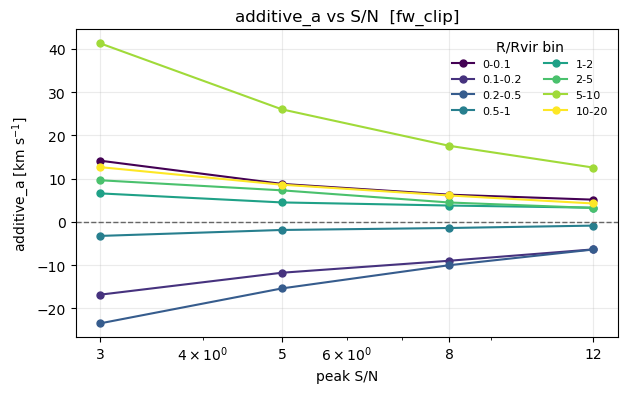

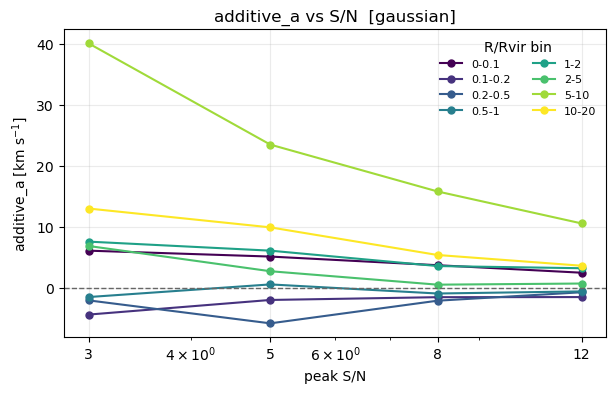

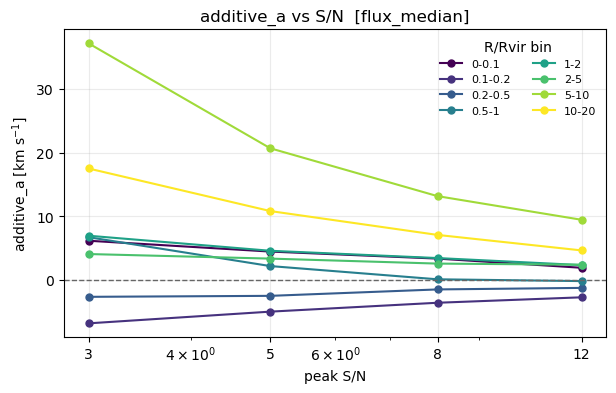

--- --- --- --- ---


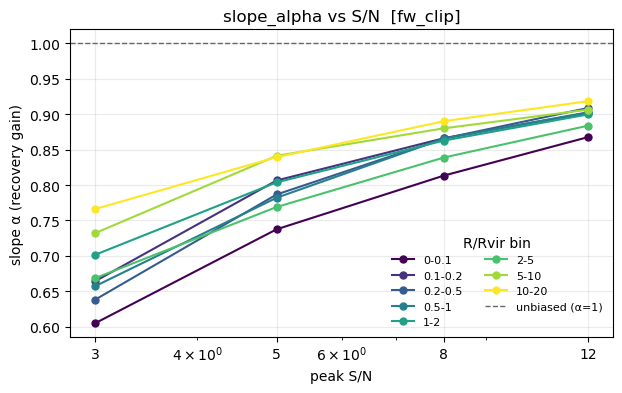

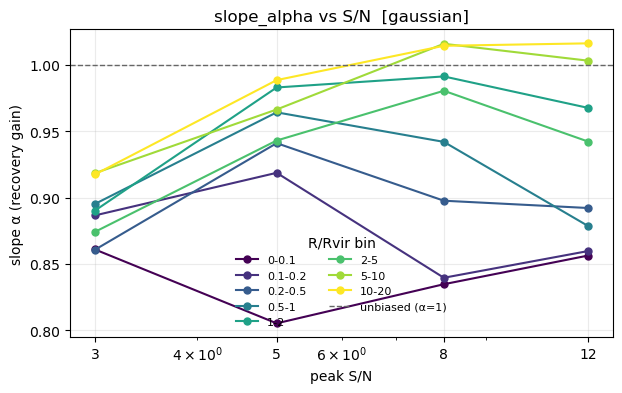

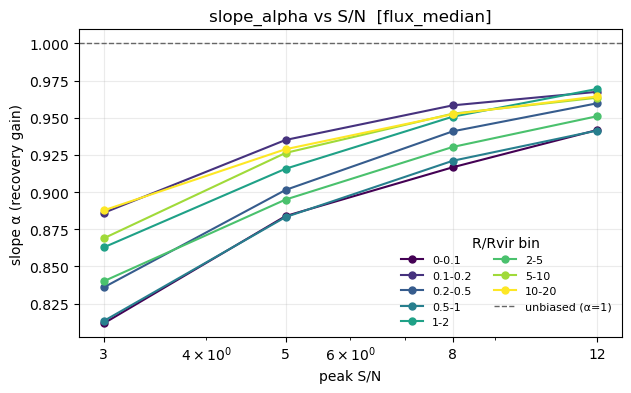

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'slope_alpha vs S/N  [flux_median]'}, xlabel='peak S/N', ylabel='slope α (recovery gain)'>)

In [28]:
###from snr_sweep import snr_sweep_matrix, plot_snr_sweep
runs = [bias_sn3, bias_sn5, bias_sn8, bias_sn12]   # any order — S/N read from each

quantity = 'additive_a' #slope_alpha, additive_a
# how each bin's compression improves with S/N, one line per bin:
plot_snr_sweep(runs, quantity=quantity, method="fw_clip", figsize=(7, 4))
plot_snr_sweep(runs, quantity=quantity, method="gaussian", figsize=(7, 4))
plot_snr_sweep(runs, quantity=quantity, method="flux_median", figsize=(7, 4))
print("--- --- --- --- ---")
quantity = 'slope_alpha' #slope_alpha, additive_a
# how each bin's compression improves with S/N, one line per bin:
plot_snr_sweep(runs, quantity=quantity, method="fw_clip", figsize=(7, 4))
plot_snr_sweep(runs, quantity=quantity, method="gaussian", figsize=(7, 4))
plot_snr_sweep(runs, quantity=quantity, method="flux_median", figsize=(7, 4))